In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [65]:
df= pd.read_csv("datasets/bundataset.csv")
# print(df.head())
df=df.drop("id",axis=1)
df.head()

,bun_size,nearby_pigeons_count,time_of_day,feeding_spot_popularity,distance_to_pigeons_m,is_raining,crumbs_on_ground,crowd_density,human_distance_m,noise_level,will_eat_bun
0,2.117397,5,11,5.183150,7.780918,0,5.472407,5,1.074004,10,0
1,1.850617,5,17,4.595100,3.644349,1,2.290217,2,3.159703,1,1
2,1.575189,1,9,1.810567,2.309359,0,3.719027,1,3.762946,1,0
3,0.790015,8,12,8.548308,5.182641,1,5.983987,10,1.948632,5,0
4,1.003298,4,19,4.046106,2.514642,0,3.413828,0,2.363299,10,1


In [66]:
df.columns

Index(['bun_size', 'nearby_pigeons_count', 'time_of_day',
       'feeding_spot_popularity', 'distance_to_pigeons_m', 'is_raining',
       'crumbs_on_ground', 'crowd_density', 'human_distance_m', 'noise_level',
       'will_eat_bun'],
      dtype='object')

In [67]:
# for i in df.columns:
#     print(i, typedf[i])
df.dtypes

bun_size                   float64
nearby_pigeons_count         int64
time_of_day                  int64
feeding_spot_popularity    float64
distance_to_pigeons_m      float64
is_raining                   int64
crumbs_on_ground           float64
crowd_density                int64
human_distance_m           float64
noise_level                  int64
will_eat_bun                 int64
dtype: object

In [68]:
df["will_eat_bun"].value_counts()

will_eat_bun
1    1203
0     797
Name: count, dtype: int64

In [69]:
categorical=[2,5,10]
binarize_categorical=[1 if i in categorical else 0 for i in range(11)]
# for i in range(11):
#     if i in categorical:
#         binarize_categorical.append(1)
#     else:0
print(binarize_categorical)

df["will_eat_bun"] = df["will_eat_bun"].astype('category')
df["is_raining"] = df["is_raining"].astype('category')
df["time_of_day"] = df["time_of_day"].astype('category')

[0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1]


In [70]:
df.dtypes

bun_size                    float64
nearby_pigeons_count          int64
time_of_day                category
feeding_spot_popularity     float64
distance_to_pigeons_m       float64
is_raining                 category
crumbs_on_ground            float64
crowd_density                 int64
human_distance_m            float64
noise_level                   int64
will_eat_bun               category
dtype: object

In [71]:
df.head()

,bun_size,nearby_pigeons_count,time_of_day,feeding_spot_popularity,distance_to_pigeons_m,is_raining,crumbs_on_ground,crowd_density,human_distance_m,noise_level,will_eat_bun
0,2.117397,5,11,5.183150,7.780918,0,5.472407,5,1.074004,10,0
1,1.850617,5,17,4.595100,3.644349,1,2.290217,2,3.159703,1,1
2,1.575189,1,9,1.810567,2.309359,0,3.719027,1,3.762946,1,0
3,0.790015,8,12,8.548308,5.182641,1,5.983987,10,1.948632,5,0
4,1.003298,4,19,4.046106,2.514642,0,3.413828,0,2.363299,10,1


In [72]:
for i in zip(df.dtypes):
    print(i)

(dtype('float64'),)
(dtype('int64'),)
(CategoricalDtype(categories=[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], ordered=False, categories_dtype=int64),)
(dtype('float64'),)
(dtype('float64'),)
(CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64),)
(dtype('float64'),)
(dtype('int64'),)
(dtype('float64'),)
(dtype('int64'),)
(CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64),)


In [73]:
# sns.heatmap(, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
corrmatrix=df.corr(numeric_only=True)
corrmatrix

,bun_size,nearby_pigeons_count,feeding_spot_popularity,distance_to_pigeons_m,crumbs_on_ground,crowd_density,human_distance_m,noise_level
bun_size,1.000000,0.005345,-0.002454,0.009005,-0.024772,-0.008896,-0.000258,-0.022802
nearby_pigeons_count,0.005345,1.000000,0.023118,-0.001373,0.003143,0.033653,-0.007726,0.002717
feeding_spot_popularity,-0.002454,0.023118,1.000000,-0.000727,-0.008898,0.041322,0.002375,-0.029120
distance_to_pigeons_m,0.009005,-0.001373,-0.000727,1.000000,-0.007258,0.026872,0.048005,0.000309
crumbs_on_ground,-0.024772,0.003143,-0.008898,-0.007258,1.000000,0.040824,-0.038271,-0.003866
crowd_density,-0.008896,0.033653,0.041322,0.026872,0.040824,1.000000,0.002557,0.012328
human_distance_m,-0.000258,-0.007726,0.002375,0.048005,-0.038271,0.002557,1.000000,0.018694
noise_level,-0.022802,0.002717,-0.029120,0.000309,-0.003866,0.012328,0.018694,1.000000


<Axes: >

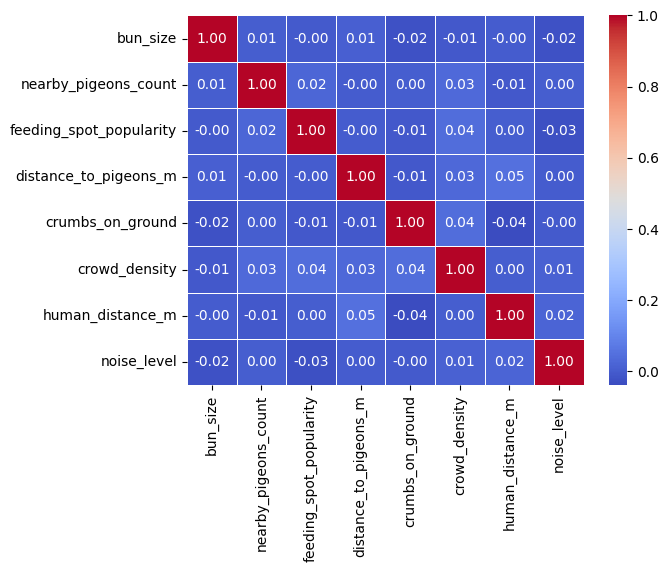

In [74]:
sns.heatmap(corrmatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# poor correlation


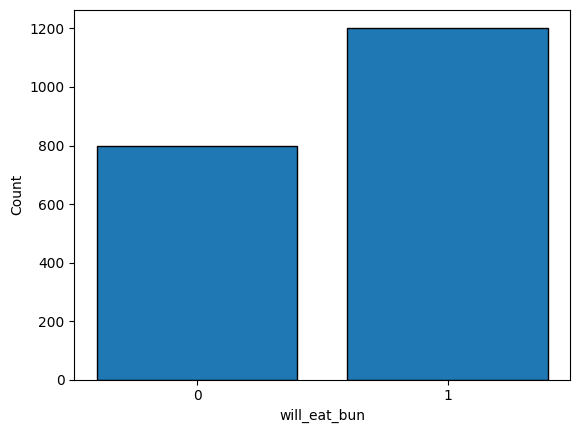

In [75]:
counts = df["will_eat_bun"].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')
plt.xticks(counts.index) # imp
plt.xlabel("will_eat_bun")
plt.ylabel("Count")
plt.show()
# imbalance class


In [76]:
# for i,j in df.items:
# for i in df:
#     # print(i)
#     # print(df[i].dtype)
# df[df[""]]
# for i,j in df.items:
#     if(df[i].dtype!="category"):
#         df[i].unique[0]

In [77]:
# plt.violinplot(df["bun_size"])
# plt.violinplot(x=df['will_eat_bun'],y=df["bun_size"])

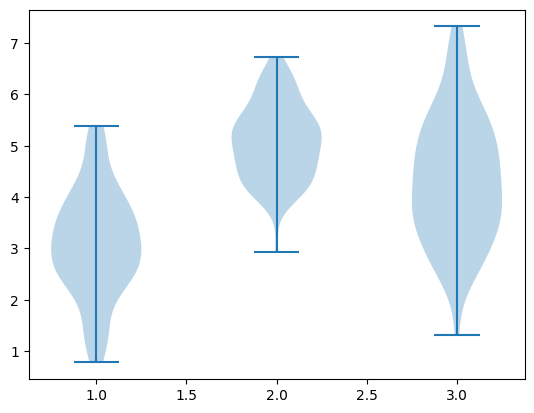

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Make data
# np.random.seed(0)
# D = np.random.normal((3, 5, 4.5), (1.00, 0.75, 1.25), (100, 3))

# # print(D)
# # Plot
# fig, ax = plt.subplots()
# vp = ax.violinplot(D)
# plt.show()


<Axes: xlabel='will_eat_bun', ylabel='bun_size'>

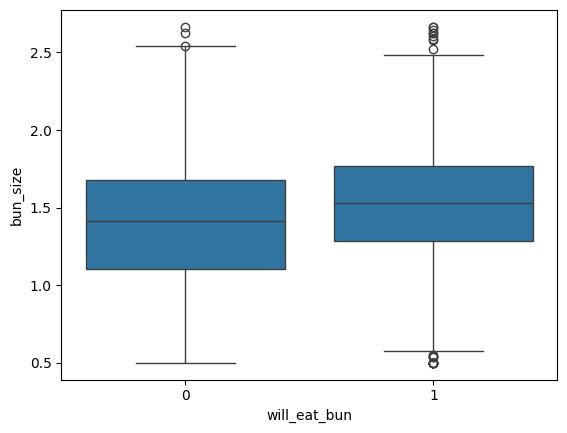

In [80]:
import seaborn as sns
import matplotlib as plt
sns.boxplot(x=df['will_eat_bun'],y=df["bun_size"])
